# BERTScore Evaluation Analysis — AffectiveTravelogue

## Scope

This is a duplicate of analysis_all however; it focuses on zero-shot prompts ONLY.

The threshold of 0.7 was defined from a rounded value from the roberta-large test paraphrase test.

In [16]:
# Cell 2 — Neo4j connection and data retrieval

import os
import warnings
import pandas as pd
from neo4j import GraphDatabase
from dotenv import load_dotenv

warnings.filterwarnings("ignore")
load_dotenv()  # reads .env in the backend directory

NEO4J_URI      = os.getenv("NEO4J_URI",      "neo4j+s://localhost:7687")
NEO4J_USER     = os.getenv("NEO4J_USER",     "neo4j")
NEO4J_PASSWORD = os.getenv("NEO4J_PASSWORD", "pXo5nUiKsadFJmW1LVBNTKUGyeAoAp2VzfFMWysGimc")

driver = GraphDatabase.driver(NEO4J_URI, auth=(NEO4J_USER, NEO4J_PASSWORD))

QUERY = """
MATCH (t:Travelogue)-[:HAS_EVALUATION]->(e:Evaluation)
WHERE (t.is_valid is null or t.is_valid <> false)
  AND e.human_waypoint_count IS NOT NULL
  AND e.ai_paragraph_count   IS NOT NULL
  AND e.human_waypoint_count = e.ai_paragraph_count
  AND t.prompt_type = 'few_shot'
  AND t.meta_prompted = TRUE
RETURN
    t.llm_model          AS llm_model,
    t.prompt_type        AS prompt_type,
    e.bertscore_f1        AS f1,
    e.bertscore_precision AS precision,
    e.bertscore_recall    AS recall,
    e.human_waypoint_count AS waypoint_count,
    e.bertscore_model      AS bertscore_model,
    e.created_at           AS evaluated_at
ORDER BY e.created_at ASC
"""

with driver.session() as session:
    records = session.run(QUERY).data()

df = pd.DataFrame(records)
df["f1"]        = df["f1"].astype(float)
df["precision"] = df["precision"].astype(float)
df["recall"]    = df["recall"].astype(float)

print(f"Valid evaluations retrieved: {len(df)}")
print(f"LLM models present:          {df['llm_model'].unique().tolist()}")
print(f"Prompt types present:        {df['prompt_type'].unique().tolist()}")
print(f"BERTScore model used:        {df['bertscore_model'].unique().tolist()}")
df.head()

Valid evaluations retrieved: 38
LLM models present:          ['gpt-oss:120b-cloud', 'gemma4:31b-cloud', 'gemma3:27b', 'glm-4.6:cloud', 'llama3.1:8b', 'gemma4:e4b']
Prompt types present:        ['few_shot']
BERTScore model used:        ['roberta-large']


,llm_model,prompt_type,f1,precision,recall,waypoint_count,bertscore_model,evaluated_at
0,gpt-oss:120b-cloud,few_shot,0.0630,0.0132,0.1110,5,roberta-large,2026-04-12T20:02:34.605213000
1,gpt-oss:120b-cloud,few_shot,0.1364,0.1279,0.1430,5,roberta-large,2026-04-12T20:02:35.141767000
2,gemma4:31b-cloud,few_shot,0.1847,0.2467,0.1219,5,roberta-large,2026-04-12T20:02:36.200363000
3,gemma4:31b-cloud,few_shot,0.2140,0.3075,0.1217,5,roberta-large,2026-04-12T20:02:37.853524000
4,gemma4:31b-cloud,few_shot,0.1897,0.2717,0.1088,5,roberta-large,2026-04-12T20:02:38.455550000


In [17]:
# Cell 3 — Descriptive statistics (mean, std, min/max per model)

import numpy as np

THRESHOLD = 0.85  # H₀ boundary

# Overall corpus stats
overall = pd.DataFrame([{
    "model": "ALL",
    "n": len(df),
    "mean_f1":   df["f1"].mean(),
    "std_f1":    df["f1"].std(ddof=1),
    "median_f1": df["f1"].median(),
    "min_f1":    df["f1"].min(),
    "max_f1":    df["f1"].max(),
    "mean_precision": df["precision"].mean(),
    "mean_recall":    df["recall"].mean(),
    "pct_above_threshold": (df["f1"] > THRESHOLD).mean() * 100,
}])

# Per-model stats
per_model = (
    df.groupby("llm_model")
    .agg(
        n=("f1", "count"),
        mean_f1=("f1", "mean"),
        std_f1=("f1", lambda x: x.std(ddof=1)),
        median_f1=("f1", "median"),
        min_f1=("f1", "min"),
        max_f1=("f1", "max"),
        mean_precision=("precision", "mean"),
        mean_recall=("recall", "mean"),
    )
    .assign(pct_above_threshold=lambda g: (df.groupby("llm_model")["f1"].apply(lambda x: (x > THRESHOLD).mean() * 100)))
    .reset_index()
    .rename(columns={"llm_model": "model"})
)

stats_table = pd.concat([overall, per_model], ignore_index=True)
stats_table = stats_table.set_index("model")

pd.set_option("display.float_format", "{:.4f}".format)
print("=== Descriptive Statistics ===")
print(stats_table.to_string())

=== Descriptive Statistics ===
                     n  mean_f1  std_f1  median_f1  min_f1  max_f1  mean_precision  mean_recall  pct_above_threshold
model                                                                                                               
ALL                 38   0.1695  0.0463     0.1679  0.0630  0.2652          0.1807       0.1568               0.0000
gemma3:27b           5   0.1316  0.0303     0.1320  0.0886  0.1618          0.1291       0.1319               0.0000
gemma4:31b-cloud     6   0.1914  0.0140     0.1915  0.1713  0.2140          0.2627       0.1203               0.0000
gemma4:e4b           2   0.1303  0.0232     0.1303  0.1139  0.1467          0.1738       0.0854               0.0000
glm-4.6:cloud        1   0.1093     NaN     0.1093  0.1093  0.1093          0.0915       0.1245               0.0000
gpt-oss:120b-cloud   2   0.0997  0.0519     0.0997  0.0630  0.1364          0.0705       0.1270               0.0000
llama3.1:8b         22   0.1847  

In [18]:
# Cell 4 — Statistical tests

from scipy import stats as sp_stats
from itertools import combinations

def run_statistical_tests(df: pd.DataFrame, threshold: float = 0.7) -> None:
    """
    Run a one-sample one-tailed t-test (H₀: μ ≤ threshold) on the full corpus
    and, where more than one LLM model is present, a Kruskal-Wallis test across
    models with pairwise Mann-Whitney U post-hoc comparisons.
    """
    f1 = df["f1"].values
    n  = len(f1)

    print("━" * 60)
    print("ONE-SAMPLE T-TEST (one-tailed, H₀: μ ≤ {:.2f})".format(threshold))
    print("━" * 60)

    # Shapiro-Wilk normality check
    if n >= 3:
        sw_stat, sw_p = sp_stats.shapiro(f1)
        print(f"  Shapiro-Wilk W = {sw_stat:.4f}, p = {sw_p:.4f}", end="")
        print("  → normally distributed" if sw_p > 0.05 else "  → non-normal (interpret t-test with caution)")

    t_stat, p_two = sp_stats.ttest_1samp(f1, popmean=threshold)
    p_one = p_two / 2 if t_stat > 0 else 1.0

    cohens_d = (f1.mean() - threshold) / f1.std(ddof=1)

    print(f"  n         = {n}")
    print(f"  mean F1   = {f1.mean():.4f}")
    print(f"  t         = {t_stat:.4f}")
    print(f"  p (one-tailed) = {p_one:.4f}", end="")
    if p_one < 0.001:
        print("  ***")
    elif p_one < 0.01:
        print("  **")
    elif p_one < 0.05:
        print("  *")
    else:
        print("  (not significant)")
    print(f"  Cohen's d = {cohens_d:.4f}  ({'small' if abs(cohens_d) < 0.5 else 'medium' if abs(cohens_d) < 0.8 else 'large'} effect)")

    decision = "REJECT H₀" if p_one < 0.05 and t_stat > 0 else "FAIL TO REJECT H₀"
    print(f"  Decision  → {decision}")

    models = df["llm_model"].unique()
    if len(models) <= 1:
        print("\n  (Only one LLM model in corpus — between-model tests skipped.)")
        return

    print()
    print("━" * 60)
    print("KRUSKAL-WALLIS TEST (between models)")
    print("━" * 60)
    groups = [df.loc[df["llm_model"] == m, "f1"].values for m in models]
    kw_stat, kw_p = sp_stats.kruskal(*groups)
    print(f"  H = {kw_stat:.4f}, p = {kw_p:.4f}", end="")
    print("  *" if kw_p < 0.05 else "  (not significant)")

    if kw_p < 0.05:
        print()
        print("  POST-HOC: Mann-Whitney U (pairwise, Bonferroni-corrected)")
        pairs = list(combinations(models, 2))
        alpha_corrected = 0.05 / len(pairs)
        for m1, m2 in pairs:
            g1 = df.loc[df["llm_model"] == m1, "f1"].values
            g2 = df.loc[df["llm_model"] == m2, "f1"].values
            u_stat, u_p = sp_stats.mannwhitneyu(g1, g2, alternative="two-sided")
            sig = "*" if u_p < alpha_corrected else "ns"
            print(f"    {m1} vs {m2}:  U = {u_stat:.1f}, p = {u_p:.4f}  [{sig}]")
        print(f"  Bonferroni α = {alpha_corrected:.4f}")
    print("━" * 60)


run_statistical_tests(df, threshold=THRESHOLD)

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
ONE-SAMPLE T-TEST (one-tailed, H₀: μ ≤ 0.85)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Shapiro-Wilk W = 0.9865, p = 0.9202  → normally distributed
  n         = 38
  mean F1   = 0.1695
  t         = -90.6014
  p (one-tailed) = 1.0000  (not significant)
  Cohen's d = -14.6975  (large effect)
  Decision  → FAIL TO REJECT H₀

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
KRUSKAL-WALLIS TEST (between models)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  H = 15.4737, p = 0.0085  *

  POST-HOC: Mann-Whitney U (pairwise, Bonferroni-corrected)
    gpt-oss:120b-cloud vs gemma4:31b-cloud:  U = 0.0, p = 0.0714  [ns]
    gpt-oss:120b-cloud vs gemma3:27b:  U = 3.0, p = 0.5714  [ns]
    gpt-oss:120b-cloud vs glm-4.6:cloud:  U = 1.0, p = 1.0000  [ns]
    gpt-oss:120b-cloud vs llama3.1:8b:  U = 3.0, p = 0.0435  [ns]
    gpt-oss:120b-cloud vs gemma4:e4b:  U = 1.0, p = 0.6667  [ns]
    gemma

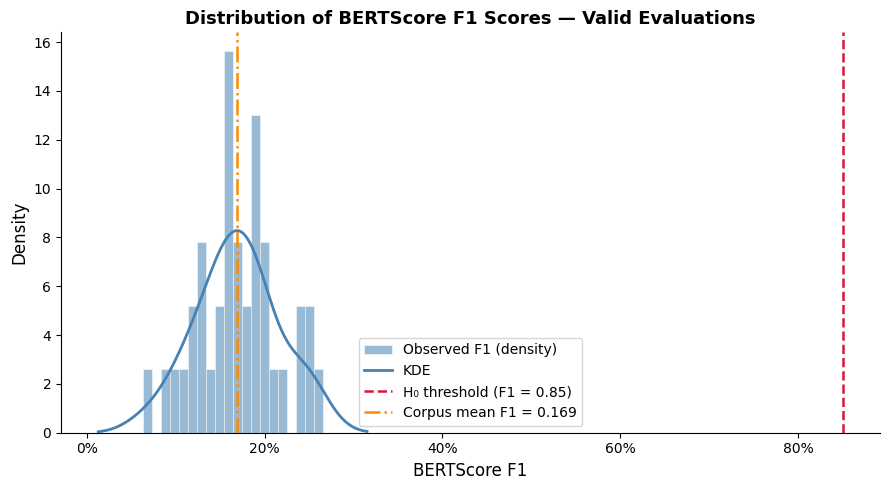

In [19]:
# Cell 5 — Histogram with KDE + threshold line at 0.7 + corpus mean line

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy.stats import gaussian_kde

fig, ax = plt.subplots(figsize=(9, 5))

f1_vals = df["f1"].values
corpus_mean = f1_vals.mean()

# Histogram
ax.hist(
    f1_vals,
    bins=20,
    color="steelblue",
    alpha=0.55,
    edgecolor="white",
    linewidth=0.6,
    density=True,
    label="Observed F1 (density)",
)

# KDE overlay
if len(f1_vals) >= 3:
    kde_x = np.linspace(max(0, f1_vals.min() - 0.05), min(1, f1_vals.max() + 0.05), 300)
    kde   = gaussian_kde(f1_vals, bw_method="scott")
    ax.plot(kde_x, kde(kde_x), color="steelblue", linewidth=2, label="KDE")

# Threshold line (H₀ boundary)
ax.axvline(
    THRESHOLD,
    color="crimson",
    linewidth=1.8,
    linestyle="--",
    label=f"H₀ threshold (F1 = {THRESHOLD})",
)

# Corpus mean line
ax.axvline(
    corpus_mean,
    color="darkorange",
    linewidth=1.8,
    linestyle="-.",
    label=f"Corpus mean F1 = {corpus_mean:.3f}",
)

ax.set_xlabel("BERTScore F1", fontsize=12)
ax.set_ylabel("Density", fontsize=12)
ax.set_title(
    "Distribution of BERTScore F1 Scores — Valid Evaluations",
    fontsize=13,
    fontweight="bold",
)
ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1.0, decimals=0))
ax.legend(fontsize=10)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig("../figures/f1_distribution_meta_fewshot.png", dpi=150, bbox_inches="tight")
plt.show()

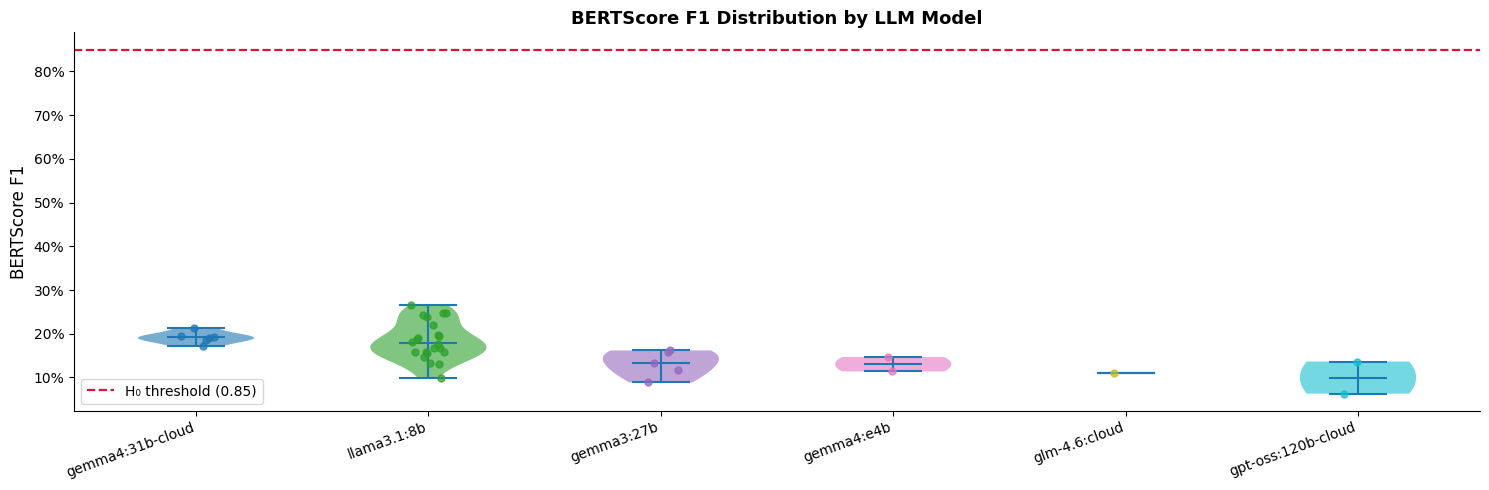

In [20]:
# Cell 6 — Violin / box plot comparing models
# If only one model is present a single violin is shown for reference.

import matplotlib.patches as mpatches

models_sorted = (
    df.groupby("llm_model")["f1"]
    .median()
    .sort_values(ascending=False)
    .index.tolist()
)

palette = plt.cm.get_cmap("tab10", len(models_sorted))
colors  = [palette(i) for i in range(len(models_sorted))]

fig, ax = plt.subplots(figsize=(max(7, len(models_sorted) * 2.5), 5))

data_by_model = [df.loc[df["llm_model"] == m, "f1"].values for m in models_sorted]

parts = ax.violinplot(
    data_by_model,
    positions=range(len(models_sorted)),
    showmedians=True,
    showextrema=True,
)

for i, (body, color) in enumerate(zip(parts["bodies"], colors)):
    body.set_facecolor(color)
    body.set_alpha(0.6)

# Overlay individual points (jittered)
rng = np.random.default_rng(42)
for i, (model, color) in enumerate(zip(models_sorted, colors)):
    vals   = df.loc[df["llm_model"] == model, "f1"].values
    jitter = rng.uniform(-0.08, 0.08, size=len(vals))
    ax.scatter(i + jitter, vals, color=color, alpha=0.75, s=25, zorder=3)

# Threshold line
ax.axhline(
    THRESHOLD,
    color="crimson",
    linewidth=1.6,
    linestyle="--",
    label=f"H₀ threshold ({THRESHOLD})",
)

ax.set_xticks(range(len(models_sorted)))
ax.set_xticklabels(models_sorted, rotation=20, ha="right", fontsize=10)
ax.set_ylabel("BERTScore F1", fontsize=12)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1.0, decimals=0))
ax.set_title(
    "BERTScore F1 Distribution by LLM Model",
    fontsize=13,
    fontweight="bold",
)
ax.legend(fontsize=10)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig("../figures/f1_by_model_violin_meta_fewshot.png", dpi=150, bbox_inches="tight")
plt.show()

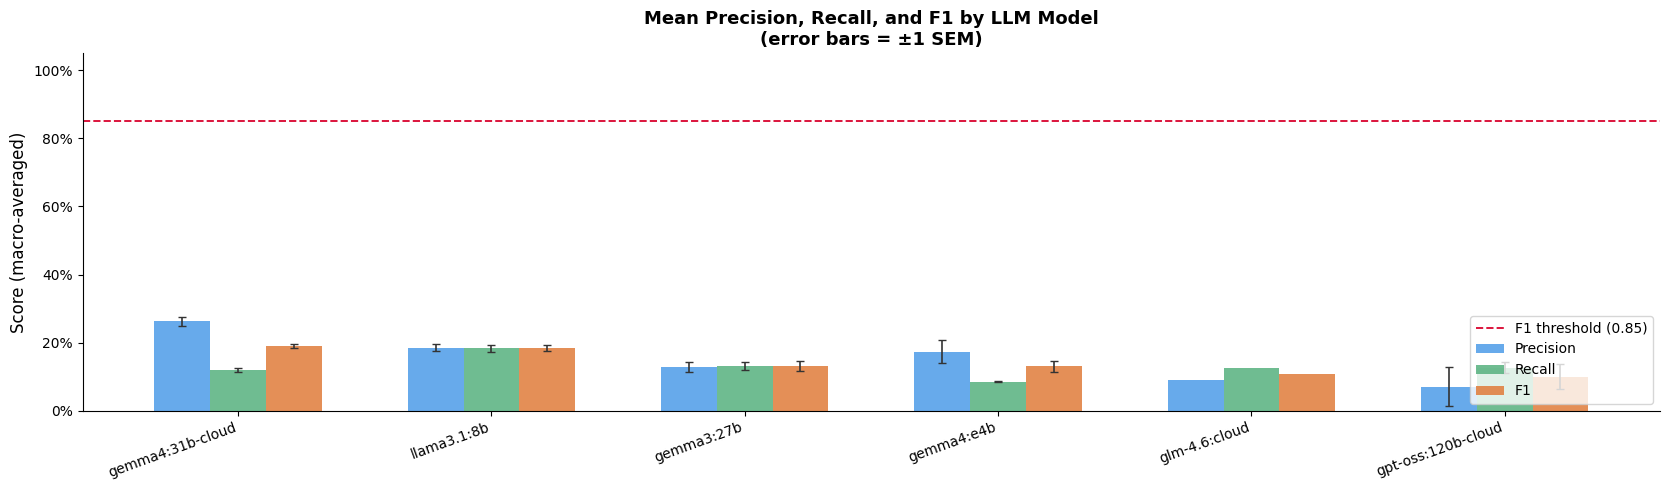

In [21]:
# Cell 7 — Precision / Recall / F1 bar chart per model

metrics = ["mean_precision", "mean_recall", "mean_f1"]
labels  = ["Precision", "Recall", "F1"]
metric_colors = ["#4C9BE8", "#56B17E", "#E07B39"]

bar_data = (
    df.groupby("llm_model")
    .agg(mean_precision=("precision", "mean"),
         mean_recall=("recall", "mean"),
         mean_f1=("f1", "mean"),
         sem_precision=("precision", lambda x: x.sem()),
         sem_recall=("recall", lambda x: x.sem()),
         sem_f1=("f1", lambda x: x.sem()))
    .loc[models_sorted]
)

n_models  = len(models_sorted)
n_metrics = len(metrics)
x         = np.arange(n_models)
width     = 0.22
offsets   = np.linspace(-(n_metrics - 1) * width / 2,
                         (n_metrics - 1) * width / 2,
                         n_metrics)

fig, ax = plt.subplots(figsize=(max(8, n_models * 2.8), 5))

for metric, label, color, offset in zip(metrics, labels, metric_colors, offsets):
    sem_col = metric.replace("mean_", "sem_")
    ax.bar(
        x + offset,
        bar_data[metric],
        width=width,
        label=label,
        color=color,
        alpha=0.85,
        yerr=bar_data[sem_col],
        capsize=3,
        error_kw={"elinewidth": 1.2, "ecolor": "#333"},
    )

ax.axhline(
    THRESHOLD,
    color="crimson",
    linewidth=1.4,
    linestyle="--",
    label=f"F1 threshold ({THRESHOLD})",
)

ax.set_xticks(x)
ax.set_xticklabels(models_sorted, rotation=20, ha="right", fontsize=10)
ax.set_ylabel("Score (macro-averaged)", fontsize=12)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1.0, decimals=0))
ax.set_ylim(0, 1.05)
ax.set_title(
    "Mean Precision, Recall, and F1 by LLM Model\n(error bars = ±1 SEM)",
    fontsize=13,
    fontweight="bold",
)
ax.legend(fontsize=10, loc="lower right")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig("../figures/precision_recall_f1_by_model_meta_fewshot.png", dpi=150, bbox_inches="tight")
plt.show()

Interpretation of Results

### Overview
